In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord

import matplotlib.pyplot as plt
from IPython.display import display
from gammapy.data import EventList
from gammapy.datasets import Datasets, MapDataset
from gammapy.irf import EDispKernelMap, PSFMap
from gammapy.maps import Map, MapAxis, WcsGeom
from gammapy.modeling import Fit
from matplotlib.patches import Circle
from astropy.table import vstack
from gammapy.data import EventList
from gammapy.catalog import SourceCatalog4FGL

import yaml
from fermipy.gtanalysis import GTAnalysis
from fermipy.plotting import ROIPlotter, SEDPlotter

catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

# Info about our initial catalogue source

In [2]:
catalog_4fgl['4FGL J1908.6+0915e']

/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/gammapy/catalog/fermi.py:218: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  ss += "{:<16s} : {:.3f}\n".format("ASSOC_PROB_BAY", d["ASSOC_PROB_BAY"])
/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/gammapy/catalog/fermi.py:219: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  ss += "{:<16s} : {:.3f}\n".format("ASSOC_PROB_LR", d["ASSOC_PROB_LR"])


# Set up of the analysis

In [3]:
gta = GTAnalysis('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/fermi_config_sgr1900_15deg_PSF1-3_two_sources_GAL_datareload.yaml', logging={'verbosity': 3})

2025-06-05 13:24:56 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.3.1 
ScienceTools version 2.2.0


In [4]:
gta.setup()

2025-06-05 13:24:56 INFO    GTAnalysis.setup(): Running setup.
2025-06-05 13:24:56 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2025-06-05 13:24:56 INFO    GTBinnedAnalysis.run_gtapp(): Running gtselect.
2025-06-05 13:24:56 INFO    GTBinnedAnalysis.run_gtapp(): time -p gtselect infile=/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL_datareload/evfile_00.txt outfile=/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL_datareload/ft1_00.fits ra=287.1600841120841 dec=9.260015061832881 rad=7.5 tmin=239557417.0 tmax=765936005.0 emin=1000.0 emax=500000.0 zmin=0.0 zmax=90.0 evclass=128 evtype=8 convtype=-1 phasemin=0.0 phasemax=1.0 evtable="EVENTS" chatter=3 clobber=yes debug=no gui=no mode="ql"
2025-06-05 13:24:56 INFO    GTBinnedAnalysis.run_gtapp(): This is gtselect version HEAD
2025-06-05 13:24:56 INFO    GTBinnedAnalysis.run_gtapp(): Applying filter string: ((EVEN

In [5]:
gta.print_model()

2025-06-05 22:32:31 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1908.6+0915e     0.000   1.276  1.06e-05   2.20       nan      1167.3     
4FGL J1910.2+0904c     0.430   0.394  9.75e-06   2.29       nan      1228.0     
4FGL J1911.0+0905      0.619   0.756  5.61e-05   2.21       nan      8143.1     
4FGL J1911.8+0903c     0.808   0.372  3.75e-06   2.15       nan       378.4     
4FGL J1912.0+0927      0.869   0.320  3.88e-06   2.95       nan       901.1     
4FGL J1908.7+0812      1.056   1.845  6.41e-06   3.36       nan      1649.4     
4FGL J1913.3+0905      1.183   0.902  7.57e-06   3.19       nan      1618.8     
4FGL J1912.7+0957      1.226   0.500  5.24e-06   3.04       nan      1253.7     
4FGL J1911.7+1014c     1.241   0.441   2.7e-06   3.19       nan       673.3     
4FGL J1913.3+1019      1.586   0.331  7.29e-06   2.17 

2025-06-05 22:32:33 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL_datareload/initial_00.xml...
2025-06-05 22:32:33 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL_datareload/initial_01.xml...
2025-06-05 22:32:33 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL_datareload/initial_02.xml...
2025-06-05 22:32:33 INFO    GTAnalysis.write_fits(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL_datareload/initial.fits...
2025-06-05 22:32:36 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 00.
2025-06-05 22:32:36 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 01.
2025-

<Figure size 2000x2000 with 0 Axes>

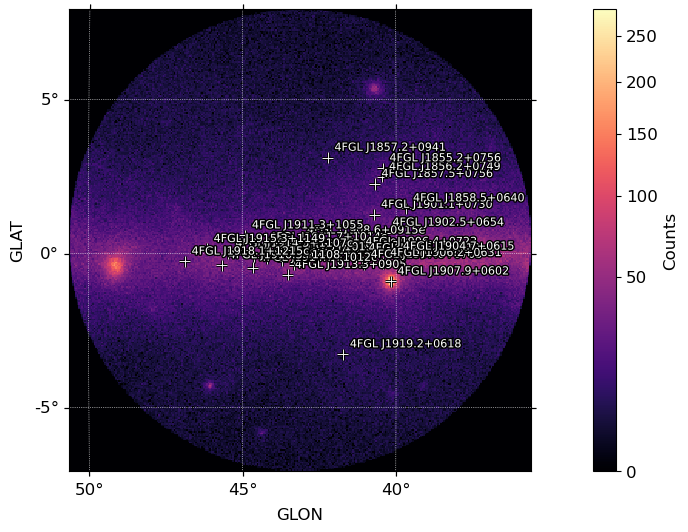

In [6]:
plt.figure(figsize=(20, 20))
gta.write_roi('initial',make_plots=True,save_model_map=True)
plt.show()

## Free parameters of the sources in the region 3 degrees around the source

In [7]:
gta.free_sources(free=False)
gta.free_sources(skydir=gta.roi[gta.roi.sources[0].name].skydir,distance=[3.0],free=True)

2025-06-05 22:32:44 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1908.6+0915e    : ['Prefactor', 'Index']
2025-06-05 22:32:44 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1910.2+0904c    : ['Prefactor', 'Index']
2025-06-05 22:32:44 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1911.0+0905     : ['norm', 'alpha', 'beta']
2025-06-05 22:32:44 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1911.8+0903c    : ['Prefactor', 'Index']
2025-06-05 22:32:44 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1912.0+0927     : ['norm', 'alpha', 'beta']
2025-06-05 22:32:44 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1908.7+0812     : ['norm', 'alpha', 'beta']
2025-06-05 22:32:44 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1913.3+0905     : ['Prefactor', 'IndexS', 'ExpfactorS']
2025-06-05 22:32:44 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1912.7+0957     : ['norm'

In [8]:
gta.optimize()
gta.fit()

2025-06-05 22:32:44 INFO    GTAnalysis.optimize(): Starting


Joint fit  ['galdiff', '4FGL J1907.9+0602', 'isodiff']


/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)


Fitting shape galdiff TS: 6877944.254
Fitting shape 4FGL J1907.9+0602 TS:  28182.362
Fitting shape 4FGL J1911.0+0905 TS:   7195.275
Fitting shape 4FGL J1906.4+0723 TS:   1932.634
Drm_Cache::update Measured counts < 0 4FGL J1906.4+0723 21 -8.22355e-13 3.93421e-13
32682.7 11833.4 4092.41 1365.8 437.28 136.169 41.8309 12.4857 3.54099 0.945573 0.233141 0.0540704 0.0116039 0.00217352 0.000345277 4.55659e-05 4.80954e-06 3.91807e-07 2.3406e-08 9.72343e-10 2.57612e-11 3.93421e-13 
Fitting shape 4FGL J1906.9+0712 TS:    861.207
Fitting shape 4FGL J1913.3+0905 TS:    479.496
Fitting shape 4FGL J1908.7+0812 TS:    316.061
Fitting shape 4FGL J1915.3+1149 TS:    248.398
Fitting shape 4FGL J1901.1+0730 TS:    244.061
Fitting shape 4FGL J1902.5+0654 TS:    234.211
Fitting shape 4FGL J1910.2+0904c TS:    226.078
Fitting shape 4FGL J1916.3+1108 TS:    212.413
Fitting shape 4FGL J1912.7+0957 TS:    203.870
Fitting shape 4FGL J1913.3+1019 TS:    178.635
Fitting shape 4FGL J1918.1+1215c TS:    163.040
Fit

2025-06-05 22:33:43 INFO    GTAnalysis.optimize(): Finished
2025-06-05 22:33:43 INFO    GTAnalysis.optimize(): LogLike: -1003422.345267 Delta-LogLike: 4580.596295
2025-06-05 22:33:43 INFO    GTAnalysis.optimize(): Execution time: 59.40 s
2025-06-05 22:33:43 INFO    GTAnalysis.fit(): Starting fit.
2025-06-05 22:35:40 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   2 Status: 102
2025-06-05 22:35:40 INFO    GTAnalysis.fit(): LogLike: -1003415.703 DeltaLogLike:        6.643 


{'fit_quality': 2,
 'fit_status': 102,
 'fit_success': True,
 'dloglike': 6.6425795630784705,
 'edm': 0.00045815125918933055,
 'loglike': -1003415.702687121,
 'covariance': array([[ 1.29505134e-03,  1.11343582e-04,  1.42300782e-04, ...,
         -3.14458704e-08,  1.50871704e-08, -2.76290392e-12],
        [ 1.11343582e-04,  1.16060942e-03,  1.31498195e-05, ...,
          4.54378145e-09, -6.58408593e-09,  4.83344074e-13],
        [ 1.42300782e-04,  1.31498195e-05,  1.63141216e-03, ...,
          4.68246282e-09, -9.76947891e-09,  6.32290474e-13],
        ...,
        [-3.14458704e-08,  4.54378145e-09,  4.68246282e-09, ...,
          7.27321678e-08,  3.47901468e-09, -2.56370135e-13],
        [ 1.50871704e-08, -6.58408593e-09, -9.76947891e-09, ...,
          3.47901468e-09,  9.23721926e-08,  3.04070105e-13],
        [-2.76290392e-12,  4.83344074e-13,  6.32290474e-13, ...,
         -2.56370135e-13,  3.04070105e-13,  5.83823618e-14]]),
 'correlation': array([[ 1.00000000e+00,  9.08194045e-02,

In [9]:
gta.print_model()

2025-06-05 22:35:40 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1908.6+0915e     0.000   1.626  1.15e-05   2.42    118.19      1713.2    *
4FGL J1910.2+0904c     0.430   0.393  9.57e-06   2.39    225.93      1371.6    *
4FGL J1911.0+0905      0.619   0.704  5.58e-05   2.21   6535.17      7717.2    *
4FGL J1911.8+0903c     0.808   0.399  4.49e-06   2.45     49.23       691.7    *
4FGL J1912.0+0927      0.869   0.351   3.6e-06   2.95     88.59       813.8    *
4FGL J1908.7+0812      1.056   1.909  7.15e-06   3.34    308.12      1890.3    *
4FGL J1913.3+0905      1.183   0.876  7.42e-06   3.15    462.29      1580.4    *
4FGL J1912.7+0957      1.226   0.568  5.13e-06   3.03    186.96      1183.1    *
4FGL J1911.7+1014c     1.241   0.340  3.24e-06   3.22     57.17       684.8    *
4FGL J1913.3+1019      1.586   0.328  6.68e-06   2.33 

In [10]:
plt.clf()
tsmap_postfit = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True)

2025-06-05 22:35:40 INFO    GTAnalysis.tsmap(): Generating TS map
2025-06-05 22:35:45 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-06-05 22:37:54 INFO    GTAnalysis.tsmap(): Finished TS map
2025-06-05 22:37:57 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL_datareload/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-06-05 22:37:57 INFO    GTAnalysis.tsmap(): Execution time: 136.51 s


<Figure size 640x480 with 0 Axes>

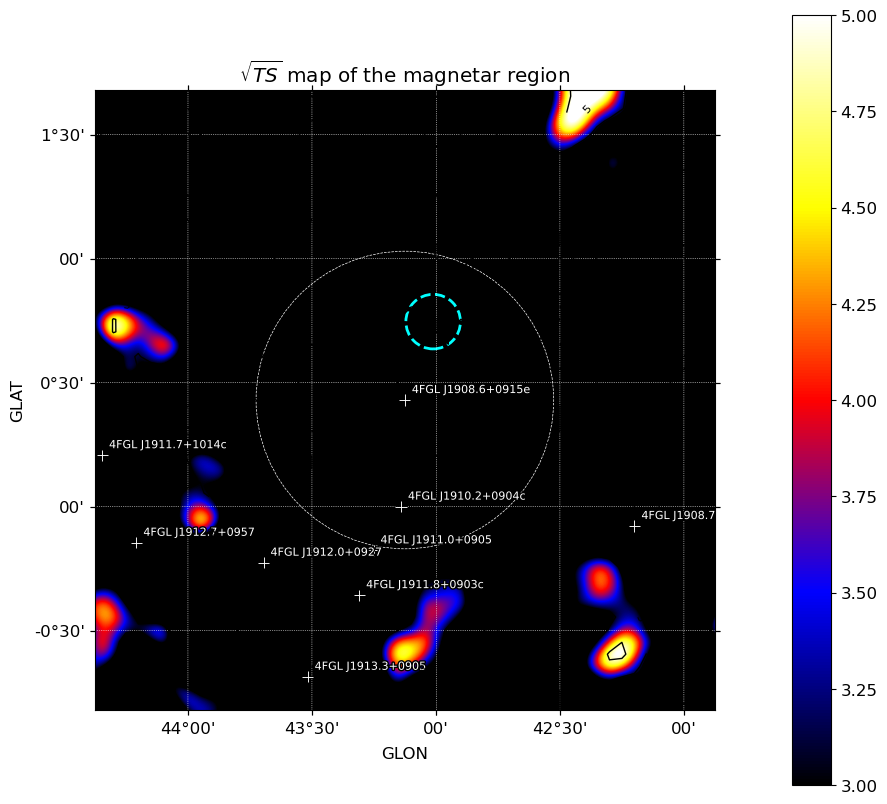

In [11]:
p = ROIPlotter(tsmap_postfit['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=5.0)  # optional threshold for labeling

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")

plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=6,vmin=3,vmax=5, levels=[0,3,5,7])
p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')

plt.title("$\sqrt{TS}$ map of the magnetar region")
plt.show()

# Exluding catalogue source from the model to see distribution of TS

In [12]:
plt.clf()
plt.clf()
tsmap_postfit_no_source = gta.tsmap(
    prefix='TSmap_no_source',
    make_plots=True,
    write_fits=True,
    write_npy=True, 
    exclude=gta.roi.sources[0].name)

2025-06-05 22:37:57 INFO    GTAnalysis.tsmap(): Generating TS map
2025-06-05 22:38:00 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-06-05 22:40:06 INFO    GTAnalysis.tsmap(): Finished TS map
2025-06-05 22:40:08 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL_datareload/TSmap_no_source_pointsource_powerlaw_2.00_tsmap.npy
2025-06-05 22:40:08 INFO    GTAnalysis.tsmap(): Execution time: 131.16 s


<Figure size 640x480 with 0 Axes>

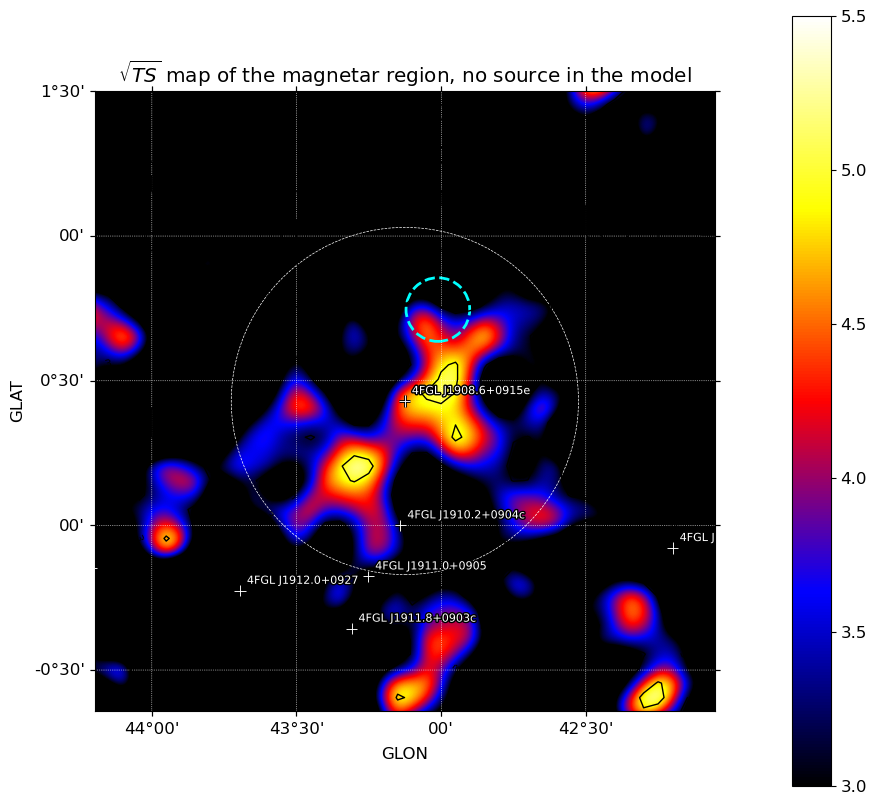

In [13]:
p = ROIPlotter(tsmap_postfit_no_source['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=5.0)  # optional threshold for labeling

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")

plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=7,vmin=3,vmax=5.5, levels=[0,3,5,7])
p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')

plt.title("$\sqrt{TS}$ map of the magnetar region, no source in the model")
plt.show()

# Split of the central source into two components

## Two extended sources

In [14]:
glon1, glat1 = 43.29, 0.2  # Bottom red circle
glon2, glat2 = 43.00,  0.47  # Central blob

c1 = SkyCoord(l=glon1*u.deg, b=glat1*u.deg, frame='galactic')
c2 = SkyCoord(l=glon2*u.deg, b=glat2*u.deg, frame='galactic')



### First need to remove the source completely from the model

In [15]:
gta.delete_source('4FGL J1908.6+0915e') 

2025-06-05 22:40:08 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1908.6+0915e


### Now lets add two new sources and fit them to check how big is the likelihood of detection ($\sqrt{TS}$) of such sources in the region

In [16]:
gta.add_source(f"Src1_extended", {
        'type':         'RadialDisc',
        'radius':        0.18,
        'glon':          c1.l.to_value(), 
        'glat':          c1.b.to_value(),
        'spectrum_type':'PowerLaw',
        'Index':        2.2,
        'Prefactor':    1e-13,
        'Scale':        1000.0
    })
gta.add_source(f"Src2_extended", {
        'type':         'RadialDisc',
        'radius':        0.18,
        'glon':          c2.l.to_value(), 
        'glat':          c2.b.to_value(),
        'spectrum_type':'PowerLaw',
        'Index':        2.2,
        'Prefactor':    1e-13,
        'Scale':        1000.0
    })

gta.print_model()

2025-06-05 22:40:09 INFO    GTAnalysis.add_source(): Adding source Src1_extended
2025-06-05 22:40:12 INFO    GTAnalysis.add_source(): Adding source Src2_extended
2025-06-05 22:40:13 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
Src2_extended          0.131   1.000  3.56e-07   2.20       nan        40.7    *
Src1_extended          0.283   1.000  3.56e-07   2.20       nan        40.7    *
4FGL J1910.2+0904c     0.430   0.393  9.57e-06   2.39    225.93      1371.6    *
4FGL J1911.0+0905      0.619   0.704  5.58e-05   2.21   6535.17      7717.2    *
4FGL J1911.8+0903c     0.808   0.399  4.49e-06   2.45     49.23       691.7    *
4FGL J1912.0+0927      0.869   0.351   3.6e-06   2.95     88.59       813.8    *
4FGL J1908.7+0812      1.056   1.909  7.15e-06   3.34    308.12      1890.3    *
4FGL J1913.3+0905      1.183   0.876  7.42e-06   3.15 

### Look on the sources that we added

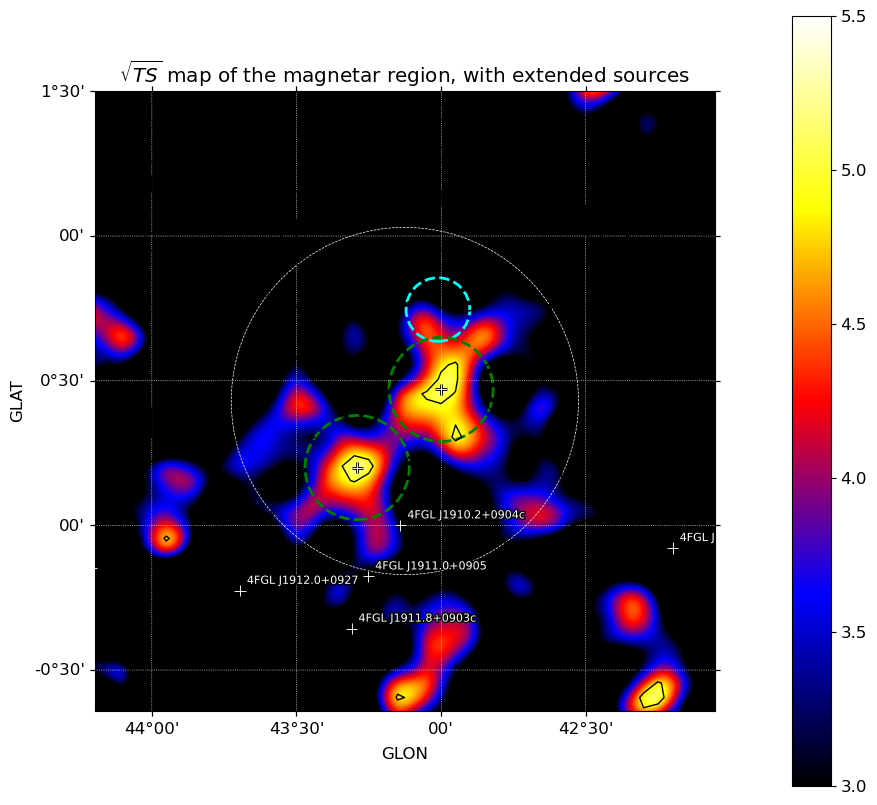

In [17]:
p = ROIPlotter(tsmap_postfit_no_source['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=5.0)  # optional threshold for labeling

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")

plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=7,vmin=3,vmax=5.5, levels=[0,3,5,7])
p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')

p.draw_circle(0.18,  # radius in degrees
              skydir=c1,
              edgecolor='green',
              linewidth=2.0,
              linestyle='--')

p.draw_circle(0.18,  # radius in degrees
              skydir=c2,
              edgecolor='green',
              linewidth=2.0,
              linestyle='--')

plt.title("$\sqrt{TS}$ map of the magnetar region, with extended sources")
plt.show()

### Fit new model

In [18]:
gta.optimize()
gta.fit()

2025-06-05 22:40:14 INFO    GTAnalysis.optimize(): Starting


Joint fit  ['galdiff', '4FGL J1907.9+0602']


/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)


Fitting shape galdiff TS: 7955371.527
Fitting shape 4FGL J1907.9+0602 TS:  27967.866
Fitting shape 4FGL J1911.0+0905 TS:   7089.448
Fitting shape 4FGL J1906.4+0723 TS:   2161.903
Fitting shape 4FGL J1906.9+0712 TS:    639.242
Fitting shape 4FGL J1913.3+0905 TS:    460.283
Fitting shape 4FGL J1908.7+0812 TS:    335.436
Fitting shape 4FGL J1910.2+0904c TS:    312.088
Fitting shape 4FGL J1901.1+0730 TS:    242.045
Fitting shape 4FGL J1902.5+0654 TS:    227.116
Fitting shape 4FGL J1915.3+1149 TS:    224.261
Fitting shape 4FGL J1912.7+0957 TS:    191.054
Fitting shape 4FGL J1916.3+1108 TS:    190.416
Fitting shape 4FGL J1913.3+1019 TS:    183.702
Fitting shape 4FGL J1918.1+1215c TS:    174.666
Fitting shape 4FGL J1914.5+1107c TS:    148.591
Fitting shape 4FGL J1858.5+0640 TS:    134.584
Fitting shape 4FGL J1907.6+0703 TS:    126.822
Fitting shape 4FGL J1904.7+0615 TS:     98.401
Fitting shape 4FGL J1912.0+0927 TS:     92.090
Fitting shape 4FGL J1914.7+1012c TS:     87.026
Fitting shape 4FGL

2025-06-05 22:41:12 INFO    GTAnalysis.optimize(): Finished
2025-06-05 22:41:12 INFO    GTAnalysis.optimize(): LogLike: -1003431.049063 Delta-LogLike: 35.246133
2025-06-05 22:41:12 INFO    GTAnalysis.optimize(): Execution time: 58.68 s
2025-06-05 22:41:12 INFO    GTAnalysis.fit(): Starting fit.
2025-06-05 22:44:32 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   2 Status: 102
2025-06-05 22:44:32 INFO    GTAnalysis.fit(): LogLike: -1003430.320 DeltaLogLike:        0.729 


{'fit_quality': 2,
 'fit_status': 102,
 'fit_success': True,
 'dloglike': 0.7288680432830006,
 'edm': 0.005870027113786705,
 'loglike': -1003430.3201947403,
 'covariance': array([[ 3.67800298e-02,  2.90051588e-02,  6.08250798e-03, ...,
         -1.49546691e-05, -8.90121802e-06, -2.53086077e-13],
        [ 2.90051588e-02,  5.73493784e-02, -9.75873467e-03, ...,
         -8.76519436e-06, -8.23839847e-06, -1.28753182e-13],
        [ 6.08250798e-03, -9.75873467e-03,  2.82446579e-02, ...,
         -3.29802908e-06, -3.45217802e-06, -1.01778768e-14],
        ...,
        [-1.49546691e-05, -8.76519436e-06, -3.29802908e-06, ...,
          2.43121208e-06,  1.85428996e-06, -3.54645380e-14],
        [-8.90121802e-06, -8.23839847e-06, -3.45217802e-06, ...,
          1.85428996e-06,  2.95005297e-06,  3.71814543e-14],
        [-2.53086077e-13, -1.28753182e-13, -1.01778768e-14, ...,
         -3.54645380e-14,  3.71814543e-14,  1.19880372e-15]]),
 'correlation': array([[ 1.00000000e+00,  6.31545801e-01, 

In [19]:
gta.print_model()

2025-06-05 22:44:32 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
Src2_extended          0.131  22.721  2.31e-06   2.98     45.54       564.4    *
Src1_extended          0.283   5.828  2.07e-06   2.20     20.92       237.3    *
4FGL J1910.2+0904c     0.430   0.424  1.03e-05   2.42    271.23      1538.8    *
4FGL J1911.0+0905      0.619   0.709  5.63e-05   2.22   6667.32      7799.5    *
4FGL J1911.8+0903c     0.808   0.396  4.42e-06   2.44     47.44       674.2    *
4FGL J1912.0+0927      0.869   0.361  3.75e-06   2.98     94.84       857.5    *
4FGL J1908.7+0812      1.056   1.947  7.28e-06   3.35    319.39      1929.9    *
4FGL J1913.3+0905      1.183   0.873   7.4e-06   3.15    459.53      1572.7    *
4FGL J1912.7+0957      1.226   0.569  5.13e-06   3.03    186.77      1183.4    *
4FGL J1911.7+1014c     1.241   0.348   3.3e-06   3.24 

In [20]:
plt.clf()
plt.clf()
tsmap_postfit_with_2_extended_sources = gta.tsmap(
    prefix='TSmap_2extended_sources',
    make_plots=True,
    write_fits=True,
    write_npy=True,)

2025-06-05 22:44:32 INFO    GTAnalysis.tsmap(): Generating TS map
2025-06-05 22:44:36 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-06-05 22:46:31 INFO    GTAnalysis.tsmap(): Finished TS map
2025-06-05 22:46:34 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_PSF1-3_GAL_datareload/TSmap_2extended_sources_pointsource_powerlaw_2.00_tsmap.npy
2025-06-05 22:46:34 INFO    GTAnalysis.tsmap(): Execution time: 121.40 s


<Figure size 640x480 with 0 Axes>

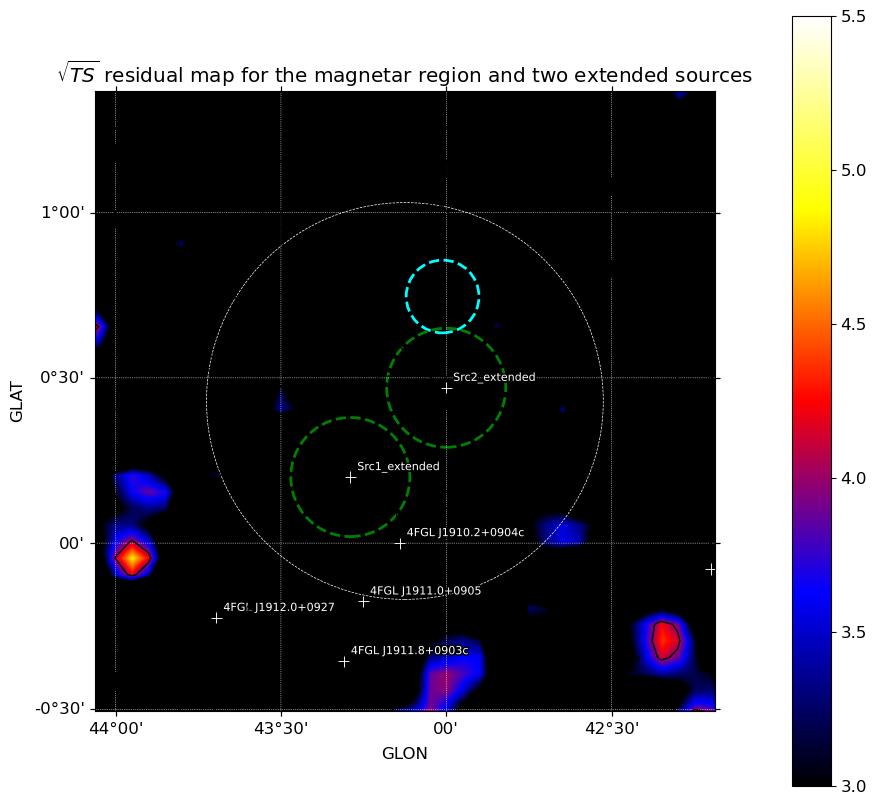

In [21]:
p = ROIPlotter(tsmap_postfit_with_2_extended_sources['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=5.0)  # optional threshold for labeling

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")

plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation="bilinear", zoom=8,vmin=3,vmax=5.5, levels=[0,3,4,5])
p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')


glon1, glat1 = 43.29, 0.2  # Bottom red circle
glon2, glat2 = 43.00,  0.47  # Central blob

c1 = SkyCoord(l=glon1*u.deg, b=glat1*u.deg, frame='galactic')
c2 = SkyCoord(l=glon2*u.deg, b=glat2*u.deg, frame='galactic')

p.draw_circle(0.18,  # radius in degrees
              skydir=c1,
              edgecolor='green',
              linewidth=2.0,
              linestyle='--')

p.draw_circle(0.18,  # radius in degrees
              skydir=c2,
              edgecolor='green',
              linewidth=2.0,
              linestyle='--')

plt.title("$\sqrt{TS}$ residual map for the magnetar region and two extended sources")
plt.show()

# Now we can find the spectrum of the source